<a href="https://colab.research.google.com/github/mp7586093-del/prog-civil-2026-1/blob/main/Copia_de_TRABAJO_PROGRAMACION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math

# ------------------------------------------------------------
# Paso 1: Funciones geométricas
# ------------------------------------------------------------
def calcular_area(b, z, y):
    """
    Calcula el área hidráulica de un canal trapezoidal.
    Parámetros:
        b (float): ancho de base (m)
        z (float): talud (H:V)
        y (float): tirante (m)
    Retorna:
        float: área (m²)
    """
    if b <= 0 or z <= 0 or y <= 0:
        raise ValueError("b, z y y deben ser positivos")
    return (b + z * y) * y

def calcular_perimetro(b, z, y):
    """
    Calcula el perímetro mojado de un canal trapezoidal.
    Parámetros:
        b (float): ancho de base (m)
        z (float): talud (H:V)
        y (float): tirante (m)
    Retorna:
        float: perímetro mojado (m)
    """
    if b <= 0 or z <= 0 or y <= 0:
        raise ValueError("b, z y y deben ser positivos")
    return b + 2 * y * math.sqrt(1 + z**2)

def calcular_ancho_superficial(b, z, y):
    """
    Calcula el ancho superficial de un canal trapezoidal.
    Parámetros:
        b (float): ancho de base (m)
        z (float): talud (H:V)
        y (float): tirante (m)
    Retorna:
        float: ancho superficial (m)
    """
    if b <= 0 or z <= 0 or y <= 0:
        raise ValueError("b, z y y deben ser positivos")
    return b + 2 * z * y

# ------------------------------------------------------------
# Paso 2: Función de caudal y velocidad
# ------------------------------------------------------------
def calcular_caudal(b, z, y, n, S):
    """
    Calcula el caudal y la velocidad usando Manning.
    Parámetros:
        b, z, y : geométricos (m, adim, m)
        n (float): coeficiente de rugosidad
        S (float): pendiente (m/m)
    Retorna:
        tuple: (Q en m³/s, V en m/s)
    """
    if n <= 0 or S <= 0:
        raise ValueError("n y S deben ser positivos")
    A = calcular_area(b, z, y)
    P = calcular_perimetro(b, z, y)
    R = A / P
    Q = (1.0 / n) * A * (R ** (2.0/3.0)) * math.sqrt(S)
    V = Q / A
    return Q, V

# ------------------------------------------------------------
# Paso 3: Clasificación del régimen
# ------------------------------------------------------------
def clasificar_regimen(Fr):
    """
    Clasifica el flujo según el número de Froude.
    Parámetros:
        Fr (float): número de Froude
    Retorna:
        str: nombre del régimen y advertencia si es supercrítico
    """
    if Fr < 1:
        return "Subcrítico"
    elif Fr == 1:
        return "Crítico"
    else:
        return "Supercrítico (¡riesgo de erosión!)"

# ------------------------------------------------------------
# Paso 4: Análisis por rango de tirantes
# ------------------------------------------------------------
def analizar_canal(b, z, n, S, y_min, y_max, paso):
    """
    Itera sobre un rango de tirantes y calcula parámetros hidráulicos.
    Parámetros:
        b, z, n, S : fijos del canal
        y_min, y_max, paso : rango de tirantes (m)
    Retorna:
        list: lista de diccionarios con resultados
    """
    g = 9.81  # aceleración gravedad (m/s²)
    resultados = []
    y = y_min
    while y <= y_max + 1e-9:  # tolerancia para evitar error de redondeo
        A = calcular_area(b, z, y)
        P = calcular_perimetro(b, z, y)
        T = calcular_ancho_superficial(b, z, y)
        R = A / P
        Q, V = calcular_caudal(b, z, y, n, S)
        Dh = A / T          # profundidad hidráulica
        Fr = V / math.sqrt(g * Dh)
        regimen = clasificar_regimen(Fr)
        resultados.append({
            'y': y,
            'A': A,
            'P': P,
            'R': R,
            'Q': Q,
            'V': V,
            'Fr': Fr,
            'Régimen': regimen
        })
        y += paso
    return resultados

# ------------------------------------------------------------
# Paso 5: Demanda agroindustrial y verificación
# ------------------------------------------------------------
def calcular_demanda_cultivo(nombre, ETo, Kc, area_ha):
    """
    Calcula el caudal necesario para un cultivo.
    Parámetros:
        nombre (str): nombre del cultivo
        ETo (float): evapotranspiración de referencia (mm/día)
        Kc (float): coeficiente de cultivo
        area_ha (float): área en hectáreas
    Retorna:
        dict: con nombre y caudal (m³/s)
    """
    area_m2 = area_ha * 10000   # 1 ha = 10000 m²
    # Conversión: mm/día * m² = L/día, luego a m³/s
    Q = (ETo * Kc * area_m2) / 86400.0
    return {'nombre': nombre, 'demanda_m3s': Q}

def verificar_abastecimiento(Q_canal, cultivos):
    """
    Compara el caudal del canal con la demanda de cada cultivo.
    Parámetros:
        Q_canal (float): caudal disponible (m³/s)
        cultivos (list): lista de dicts con 'nombre' y 'demanda_m3s'
    Retorna:
        None (imprime resultados)
    """
    print("\n" + "="*60)
    print(f"VERIFICACIÓN DE ABASTECIMIENTO (Q_canal = {Q_canal:.4f} m³/s)")
    print("-"*60)
    for cult in cultivos:
        demanda = cult['demanda_m3s']
        if Q_canal >= demanda:
            estado = "✓ Abastece"
        else:
            estado = "✗ NO abastece"
        print(f"{cult['nombre']:10} : demanda {demanda:.4f} m³/s  →  {estado}")

# ------------------------------------------------------------
# Paso 6: Programa principal
# ------------------------------------------------------------
def main():
    # Parámetros del canal
    b = 0.80      # m
    z = 1.5       # talud
    n = 0.014     # concreto liso
    S = 0.0008    # pendiente
    y_min = 0.20
    y_max = 1.20
    paso = 0.20

    # Análisis hidráulico
    resultados = analizar_canal(b, z, n, S, y_min, y_max, paso)

    # Tabla de resultados (similar a la esperada)
    print("\n" + "="*80)
    print("RESULTADOS DEL ANÁLISIS HIDRÁULICO (Canal trapezoidal)")
    print("="*80)
    print(f"{'y (m)':>6} {'A (m²)':>8} {'Q (m³/s)':>10} {'Fr':>7} {'Régimen':>20}")
    print("-"*60)
    for r in resultados:
        print(f"{r['y']:6.2f} {r['A']:8.3f} {r['Q']:10.4f} {r['Fr']:7.3f} {r['Régimen']:>20}")

    # Datos de cultivos (demanda con y=0.80 m -> Q ≈ 0.663 m³/s)
    cultivos_data = [
        {"nombre": "Maíz",   "ETo": 5.2, "Kc": 1.05, "area_ha": 40},
        {"nombre": "Arroz",  "ETo": 6.0, "Kc": 1.20, "area_ha": 350},
        {"nombre": "Palma",  "ETo": 5.5, "Kc": 1.10, "area_ha": 600},
        {"nombre": "Caña",   "ETo": 5.8, "Kc": 1.25, "area_ha": 800}
    ]

    cultivos_demanda = []
    for c in cultivos_data:
        cultivos_demanda.append(calcular_demanda_cultivo(c["nombre"], c["ETo"], c["Kc"], c["area_ha"]))

    # Caudal de diseño para y = 0.80 m (tomado de la tabla)
    Q_diseno = 0.6633   # m³/s
    verificar_abastecimiento(Q_diseno, cultivos_demanda)

    # --------------------------------------------------------
    # RETO DE DISEÑO (opcional): encontrar tirante mínimo para abastecer TODOS los cultivos
    # --------------------------------------------------------
    print("\n" + "="*60)
    print("RETO DE DISEÑO: Tirante mínimo que abastece a todos los cultivos")
    print("-"*60)
    # Calcular demanda total (suma de todos los cultivos)
    demanda_total = sum(c['demanda_m3s'] for c in cultivos_demanda)
    print(f"Demanda total de los cultivos = {demanda_total:.4f} m³/s")

    # Buscar tirante mínimo (while con paso fino)
    y_test = 0.20
    paso_fino = 0.01
    encontrado = None
    while y_test <= 2.0:   # límite superior razonable
        try:
            Q_test, _ = calcular_caudal(b, z, y_test, n, S)
            if Q_test >= demanda_total:
                encontrado = y_test
                break
        except:
            pass
        y_test += paso_fino

    if encontrado:
        print(f"✓ El tirante mínimo para abastecer todos los cultivos es y ≈ {encontrado:.2f} m")
        Q_min, _ = calcular_caudal(b, z, encontrado, n, S)
        print(f"  Caudal correspondiente: {Q_min:.4f} m³/s")
    else:
        print("✗ No se encontró tirante dentro del rango explorado (hasta 2.0 m)")

if __name__ == "__main__":
    main()


RESULTADOS DEL ANÁLISIS HIDRÁULICO (Canal trapezoidal)
 y (m)   A (m²)   Q (m³/s)      Fr              Régimen
------------------------------------------------------------
  0.20    0.220     0.1225   0.448           Subcrítico
  0.40    0.560     0.4487   0.483           Subcrítico
  0.60    1.020     1.0121   0.506           Subcrítico
  0.80    1.600     1.8537   0.523           Subcrítico
  1.00    2.300     3.0128   0.538           Subcrítico
  1.20    3.120     4.5267   0.550           Subcrítico

VERIFICACIÓN DE ABASTECIMIENTO (Q_canal = 0.6633 m³/s)
------------------------------------------------------------
Maíz       : demanda 25.2778 m³/s  →  ✗ NO abastece
Arroz      : demanda 291.6667 m³/s  →  ✗ NO abastece
Palma      : demanda 420.1389 m³/s  →  ✗ NO abastece
Caña       : demanda 671.2963 m³/s  →  ✗ NO abastece

RETO DE DISEÑO: Tirante mínimo que abastece a todos los cultivos
------------------------------------------------------------
Demanda total de los cultivos = 1408

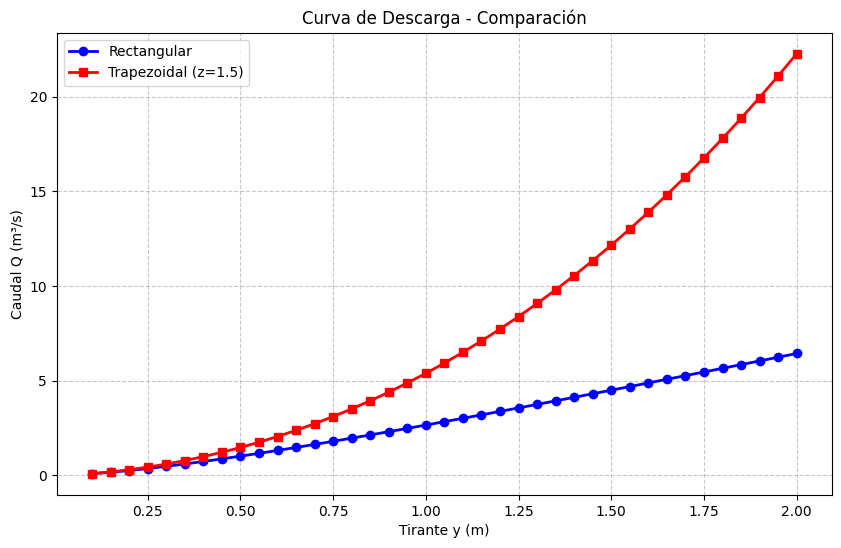

In [ ]:
import matplotlib.pyplot as plt

# Parámetros comunes (ajústalos si usaste otros valores)
b = 2.0          # ancho de base (m)
n = 0.015        # rugosidad
S = 0.001        # pendiente
z = 1.5          # talud

# Generar lista de tirantes (de 0.1 a 2.0 m, paso 0.05 m)
tirantes = []
y = 0.1
while y <= 2.0 + 0.0001:
    tirantes.append(round(y, 3))
    y += 0.05

# Listas para caudales
caudales_rect = []
caudales_trap = []

# Funciones (deben estar definidas en celdas anteriores)
# Si ya las definiste globalmente, no necesitas redefinirlas.
# Pero por si acaso, aquí van las necesarias:

def area_rectangular(b, y):
    return b * y

def perimetro_rectangular(b, y):
    return b + 2 * y

def caudal_rectangular(b, y, n, S):
    A = area_rectangular(b, y)
    P = perimetro_rectangular(b, y)
    R = A / P
    Q = (1.0/n) * A * (R**(2/3)) * (S**0.5)
    return Q

def area_trapezoidal(b, z, y):
    return (b + z*y) * y

def perimetro_trapezoidal(b, z, y):
    return b + 2*y*(1 + z**2)**0.5

def caudal_trapezoidal(b, z, y, n, S):
    A = area_trapezoidal(b, z, y)
    P = perimetro_trapezoidal(b, z, y)
    R = A / P
    Q = (1.0/n) * A * (R**(2/3)) * (S**0.5)
    return Q

# Calcular caudales
for y in tirantes:
    Qr = caudal_rectangular(b, y, n, S)
    Qt = caudal_trapezoidal(b, z, y, n, S)
    caudales_rect.append(Qr)
    caudales_trap.append(Qt)

# Graficar
plt.figure(figsize=(10,6))
plt.plot(tirantes, caudales_rect, 'b-o', label='Rectangular', linewidth=2)
plt.plot(tirantes, caudales_trap, 'r-s', label='Trapezoidal (z=1.5)', linewidth=2)
plt.xlabel('Tirante y (m)')
plt.ylabel('Caudal Q (m³/s)')
plt.title('Curva de Descarga - Comparación')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()